In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, csv, json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

import numpy.ma as ma
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import xarray as xr
import json
import ast

In [2]:
input_dir = '/umbc/rs/pi_zzbatmos/users/kn82613/My_WORK/PACA_SoC_Algorithm/V1/'
ds = xr.open_dataset(
    os.path.join(input_dir, 'PACE_SoC_retrieval.nc'),
    engine='netcdf4'
)

In [3]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:         (y: 216, x: 189, wl: 6)
Coordinates:
  * y               (y) int64 2kB 0 1 2 3 4 5 6 ... 209 210 211 212 213 214 215
  * x               (x) int64 2kB 0 1 2 3 4 5 6 ... 182 183 184 185 186 187 188
  * wl              (wl) int64 48B 0 1 2 3 4 5
Data variables: (12/18)
    sample          (y, x) float32 163kB ...
    CER_retr        (y, x) float32 163kB ...
    COT_retr        (y, x) float32 163kB ...
    AOD_retr        (y, x) float32 163kB ...
    converged       (y, x) bool 41kB ...
    PostStd_CER     (y, x) float32 163kB ...
    ...              ...
    SIC_CER_bits    (y, x) float32 163kB ...
    SIC_COT_bits    (y, x) float32 163kB ...
    SIC_AOD_bits    (y, x) float32 163kB ...
    SIC_total_bits  (y, x) float32 163kB ...
    Observed_R      (y, x, wl) float32 980kB ...
    Predicted_R     (y, x, wl) float32 980kB ...

In [4]:
bad = (
    (ds["CER_retr"]  > 40)    |
    (ds["CER_retr"]  < 4)    |
    (ds["COT_retr"]  > 158.8) |
    (ds["AOD_retr"]  > 4)     |
    (ds["COT_retr"]  < 1)     |
    (ds["DOFS_CER"]  < 0.6)   |
    (ds["DOFS_COT"]  < 0.6)   |
    (ds["DOFS_AOD"]  < 0.6)   |
    (ds["DOFS_total"] < 2)    |
    (ds["converged"] == False)
)

# keep good pixels
ds_clean = ds.where(~bad)

print(ds_clean)

<xarray.Dataset> Size: 5MB
Dimensions:         (y: 216, x: 189, wl: 6)
Coordinates:
  * y               (y) int64 2kB 0 1 2 3 4 5 6 ... 209 210 211 212 213 214 215
  * x               (x) int64 2kB 0 1 2 3 4 5 6 ... 182 183 184 185 186 187 188
  * wl              (wl) int64 48B 0 1 2 3 4 5
Data variables: (12/18)
    sample          (y, x) float32 163kB 0.0 nan 2.0 ... 4.082e+04 4.082e+04
    CER_retr        (y, x) float32 163kB 17.5 nan 18.3 18.0 ... 13.03 12.79 12.4
    COT_retr        (y, x) float32 163kB 19.06 nan 17.32 ... 30.78 25.28 27.95
    AOD_retr        (y, x) float32 163kB 0.5871 nan 0.6727 ... 1.212 1.127 1.198
    converged       (y, x) float64 327kB 1.0 nan 1.0 1.0 nan ... nan 1.0 1.0 1.0
    PostStd_CER     (y, x) float32 163kB 1.079 nan 1.099 ... 1.365 1.395 0.8476
    ...              ...
    SIC_CER_bits    (y, x) float32 163kB 4.534 nan 4.507 ... 4.195 4.164 4.882
    SIC_COT_bits    (y, x) float32 163kB 3.963 nan 4.161 ... 2.071 2.923 2.08
    SIC_AOD_bits    (y, 

In [5]:
dss = xr.open_dataset(
    os.path.join(input_dir, 'PACE_OCI.20250822T123146.L1B.V3.nc'),
    engine='netcdf4'
)

obs_data = xr.open_dataset(dss.encoding["source"], group="observation_data")
geo_data = xr.open_dataset(dss.encoding["source"], group="geolocation_data")

# Extract lat/lon
lat2d = geo_data["latitude"]
lon2d = geo_data["longitude"]

In [6]:
# 2. Define your target lat/lon box
lat_min, lat_max = -10, -8    # S is -ve
lon_min, lon_max = 9, 11    # E is +ve

# 3. Build a boolean mask of pixels inside that box
mask = (
    (lat2d >= lat_min) & (lat2d <= lat_max) &
    (lon2d >= lon_min) & (lon2d <= lon_max)
)

# 4. Find the minimal row/col extents that cover the mask
rows = np.any(mask, axis=1)
cols = np.any(mask, axis=0)

i0, i1 = np.where(rows)[0][[0, -1]]
j0, j1 = np.where(cols)[0][[0, -1]]
i1 += 1  # make Python slice end-inclusive
j1 += 1

# 5. Slice out each bands small patch
blue_sub  = obs_data['rhot_blue'].isel(blue_bands=64)[i0:i1, j0:j1]
red_sub   = obs_data['rhot_red'].isel(red_bands =33)[i0:i1, j0:j1]
green_sub = obs_data['rhot_blue'].isel(blue_bands=92)[i0:i1, j0:j1]  # correct green

In [7]:
# 6. Build an RGB array, scale & clamp to [0,1]
factor = 0.4
rgb_sub = np.stack([
    red_sub   / factor,
    green_sub / factor,
    blue_sub  / factor
], axis=-1)
np.clip(rgb_sub, 0, 1, out=rgb_sub)

array([[[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.92535985, 0.86433244, 0.8863613 ],
        [0.94980246, 0.8768051 , 0.8924943 ],
        [0.87066156, 0.8244958 , 0.85563076]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.9499279 , 0.8772443 , 0.89275897],
        [0.925447  , 0.8607653 , 0.8813978 ],
        [0.8585346 , 0.81617624, 0.8478072 ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.93624204, 0.86516887, 0.88325864],
        [0.9146885 , 0.850712  , 0.8725089 ],
        [0.8634594 , 0.81675863, 0.84743524]],

       ...,

       [[0.8012149 , 0.7958409 , 0.8458031 ],
        [0.8458267 , 0.8277922 , 0.86909807],
        [0.87000287, 0

Colorbar ranges:
CER (np.float32(7.3709044), np.float32(20.552925))
COT (np.float32(4.396946), np.float32(45.912724))
AOD (np.float32(0.44051734), np.float32(1.3307796))
lon_plot shape: (216, 189)
lat_plot shape: (216, 189)
CER_map shape: (216, 189)
COT_map shape: (216, 189)
AOD_map shape: (216, 189)
rgb_sub shape: (216, 189, 3)


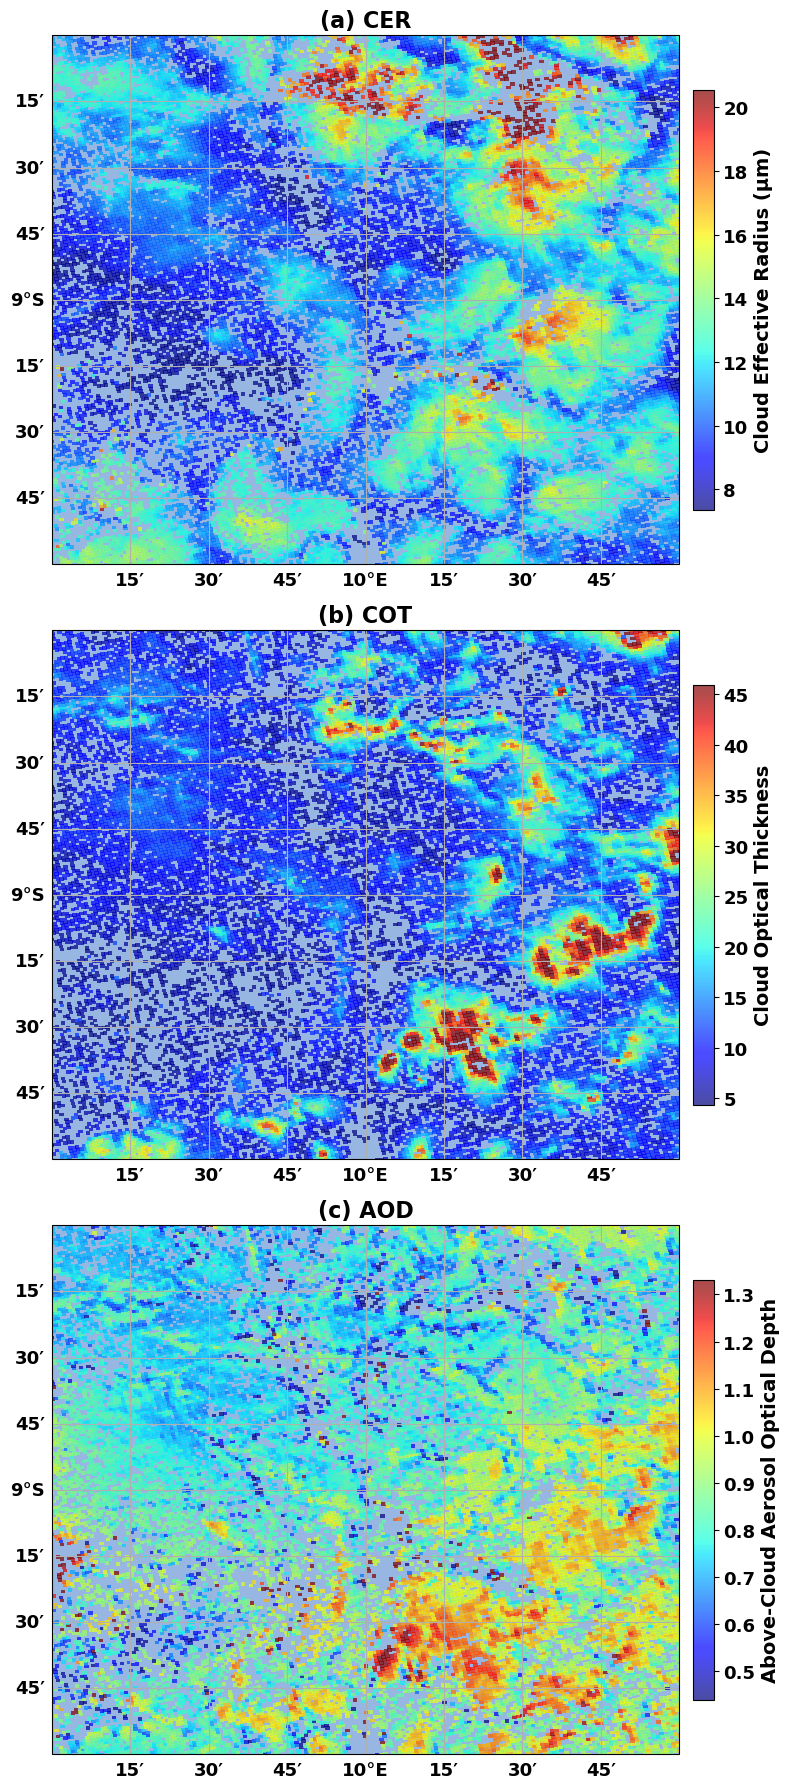

In [9]:
# --------------------------------------------
# Read retrieval maps from NetCDF
# --------------------------------------------
CER_map = ds_clean["CER_retr"].values
COT_map = ds_clean["COT_retr"].values
AOD_map = ds_clean["AOD_retr"].values

# ---- Prepare masked arrays ----
masked_CER = np.ma.masked_invalid(CER_map)
masked_COT = np.ma.masked_invalid(COT_map)
masked_AOD = np.ma.masked_invalid(AOD_map)

param_maps = {
    'CER': masked_CER,
    'COT': masked_COT,
    'AOD': masked_AOD
}

cbar_labels = {
    'CER': 'Cloud Effective Radius (µm)',
    'COT': 'Cloud Optical Thickness',
    'AOD': 'Above-Cloud Aerosol Optical Depth'
}

titles = {
    'CER': '(a) CER',
    'COT': '(b) COT',
    'AOD': '(c) AOD'
}

# --------------------------------------------
# Compute dynamic colorbar ranges (1st–99th percentile)
# --------------------------------------------
cbar_ranges = {}
for param, grid in param_maps.items():
    valid = grid.compressed()
    if len(valid) > 0:
        vmin = np.percentile(valid, 1)
        vmax = np.percentile(valid, 99)
    else:
        vmin, vmax = np.nan, np.nan
    cbar_ranges[param] = (vmin, vmax)

print("Colorbar ranges:")
for param in cbar_ranges:
    print(param, cbar_ranges[param])

# --------------------------------------------
# Coordinates for retrieval grid
# IMPORTANT: use coordinates matching retrieval shape
# --------------------------------------------
lon_plot = lon2d[i0:i1, j0:j1]
lat_plot = lat2d[i0:i1, j0:j1]

print("lon_plot shape:", lon_plot.shape)
print("lat_plot shape:", lat_plot.shape)
print("CER_map shape:", CER_map.shape)
print("COT_map shape:", COT_map.shape)
print("AOD_map shape:", AOD_map.shape)
print("rgb_sub shape:", rgb_sub.shape)

# If retrieval maps and lat/lon subset shapes do not match,
# do not use the cropped RGB overlay
use_rgb = (rgb_sub.shape[:2] == CER_map.shape) and (lon_plot.shape == CER_map.shape)

# --------------------------------------------
# Colormaps
# --------------------------------------------
cmap_dict = {
    'CER': plt.cm.jet.copy(),
    'COT': plt.cm.jet.copy(),
    'AOD': plt.cm.jet.copy()
}

for cmap in cmap_dict.values():
    cmap.set_bad(alpha=0)

# --------------------------------------------
# Create vertical figure
# --------------------------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 18),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (param, grid) in zip(axes, param_maps.items()):

    # --------------------------------------------
    # RGB background only if shape matches
    # --------------------------------------------
    if use_rgb:
        ax.imshow(
            rgb_sub,
            origin='upper',
            extent=[
                np.nanmin(lon_plot), np.nanmax(lon_plot),
                np.nanmin(lat_plot), np.nanmax(lat_plot)
            ],
            transform=ccrs.PlateCarree(),
            aspect='auto'
        )

    # --------------------------------------------
    # Retrieval overlay
    # --------------------------------------------
    cs = ax.pcolormesh(
        lon_plot,
        lat_plot,
        grid,
        cmap=cmap_dict[param],
        shading='nearest',
        vmin=cbar_ranges[param][0],
        vmax=cbar_ranges[param][1],
        alpha=0.70 if use_rgb else 1.0,
        transform=ccrs.PlateCarree()
    )

    # --------------------------------------------
    # Map formatting
    # --------------------------------------------
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=1.0)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.xlabel_style = {'size': 13, 'weight': 'bold'}
    gl.ylabel_style = {'size': 13, 'weight': 'bold'}

    ax.set_title(titles[param], fontsize=16, fontweight='bold')

    # --------------------------------------------
    # Colorbar
    # --------------------------------------------
    cbar = fig.colorbar(cs, ax=ax, fraction=0.0317, pad=0.02)
    cbar.ax.tick_params(labelsize=13)
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    cbar.set_label(
        cbar_labels[param],
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Colorbar ranges:
CER (np.float32(0.6880671), np.float32(2.665067))
COT (np.float32(0.37324113), np.float32(13.751954))
AOD (np.float32(0.106961265), np.float32(1.0010781))
lon_plot shape: (216, 189)
lat_plot shape: (216, 189)
CER_map shape: (216, 189)
COT_map shape: (216, 189)
AOD_map shape: (216, 189)
rgb_sub shape: (216, 189, 3)


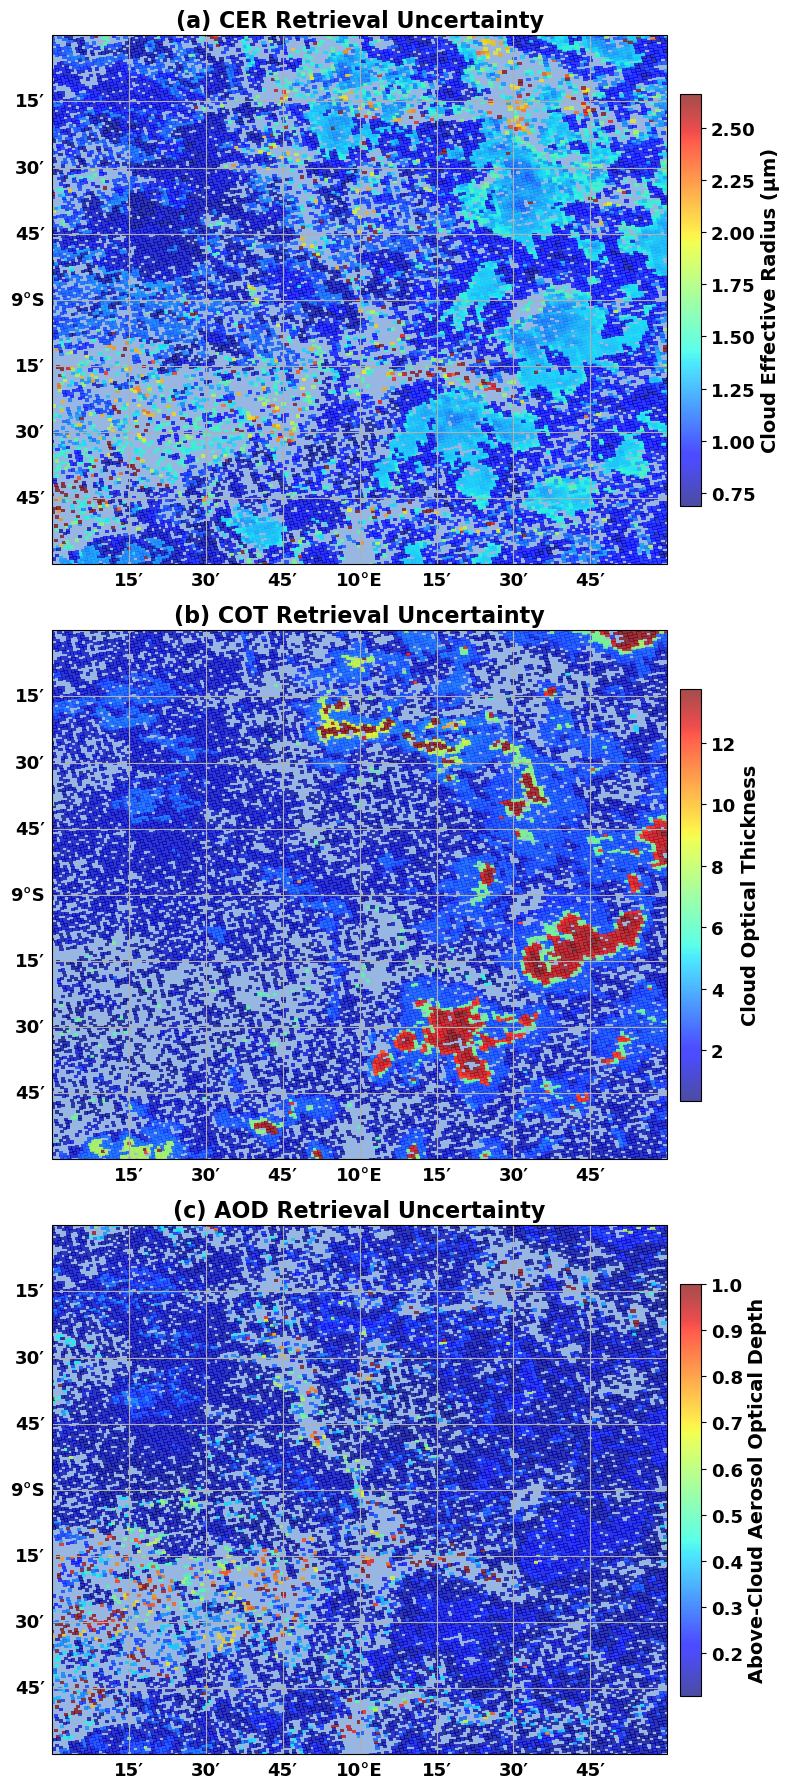

In [14]:
# --------------------------------------------
# Read retrieval maps from NetCDF
# --------------------------------------------
CER_map = ds_clean["PostStd_CER"].values
COT_map = ds_clean["PostStd_COT"].values
AOD_map = ds_clean["PostStd_AOD"].values

# ---- Prepare masked arrays ----
masked_CER = np.ma.masked_invalid(CER_map)
masked_COT = np.ma.masked_invalid(COT_map)
masked_AOD = np.ma.masked_invalid(AOD_map)

param_maps = {
    'CER': masked_CER,
    'COT': masked_COT,
    'AOD': masked_AOD
}

cbar_labels = {
    'CER': 'Cloud Effective Radius (µm)',
    'COT': 'Cloud Optical Thickness',
    'AOD': 'Above-Cloud Aerosol Optical Depth'
}

titles = {
    'CER': '(a) CER Retrieval Uncertainty',
    'COT': '(b) COT Retrieval Uncertainty',
    'AOD': '(c) AOD Retrieval Uncertainty'
}

# --------------------------------------------
# Compute dynamic colorbar ranges (1st–99th percentile)
# --------------------------------------------
cbar_ranges = {}
for param, grid in param_maps.items():
    valid = grid.compressed()
    if len(valid) > 0:
        vmin = np.percentile(valid, 1)
        vmax = np.percentile(valid, 99)
    else:
        vmin, vmax = np.nan, np.nan
    cbar_ranges[param] = (vmin, vmax)

print("Colorbar ranges:")
for param in cbar_ranges:
    print(param, cbar_ranges[param])

# --------------------------------------------
# Coordinates for retrieval grid
# IMPORTANT: use coordinates matching retrieval shape
# --------------------------------------------
lon_plot = lon2d[i0:i1, j0:j1]
lat_plot = lat2d[i0:i1, j0:j1]

print("lon_plot shape:", lon_plot.shape)
print("lat_plot shape:", lat_plot.shape)
print("CER_map shape:", CER_map.shape)
print("COT_map shape:", COT_map.shape)
print("AOD_map shape:", AOD_map.shape)
print("rgb_sub shape:", rgb_sub.shape)

# If retrieval maps and lat/lon subset shapes do not match,
# do not use the cropped RGB overlay
use_rgb = (rgb_sub.shape[:2] == CER_map.shape) and (lon_plot.shape == CER_map.shape)

# --------------------------------------------
# Colormaps
# --------------------------------------------
cmap_dict = {
    'CER': plt.cm.jet.copy(),
    'COT': plt.cm.jet.copy(),
    'AOD': plt.cm.jet.copy()
}

for cmap in cmap_dict.values():
    cmap.set_bad(alpha=0)

# --------------------------------------------
# Create vertical figure
# --------------------------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 18),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (param, grid) in zip(axes, param_maps.items()):

    # --------------------------------------------
    # RGB background only if shape matches
    # --------------------------------------------
    if use_rgb:
        ax.imshow(
            rgb_sub,
            origin='upper',
            extent=[
                np.nanmin(lon_plot), np.nanmax(lon_plot),
                np.nanmin(lat_plot), np.nanmax(lat_plot)
            ],
            transform=ccrs.PlateCarree(),
            aspect='auto'
        )

    # --------------------------------------------
    # Retrieval overlay
    # --------------------------------------------
    cs = ax.pcolormesh(
        lon_plot,
        lat_plot,
        grid,
        cmap=cmap_dict[param],
        shading='nearest',
        vmin=cbar_ranges[param][0],
        vmax=cbar_ranges[param][1],
        alpha=0.70 if use_rgb else 1.0,
        transform=ccrs.PlateCarree()
    )

    # --------------------------------------------
    # Map formatting
    # --------------------------------------------
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=1.0)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.xlabel_style = {'size': 13, 'weight': 'bold'}
    gl.ylabel_style = {'size': 13, 'weight': 'bold'}

    ax.set_title(titles[param], fontsize=16, fontweight='bold')

    # --------------------------------------------
    # Colorbar
    # --------------------------------------------
    cbar = fig.colorbar(cs, ax=ax, fraction=0.0317, pad=0.02)
    cbar.ax.tick_params(labelsize=13)
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    cbar.set_label(
        cbar_labels[param],
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Colorbar ranges:
CER (np.float32(0.9886358), np.float32(0.9992425))
COT (np.float32(0.9243534), np.float32(0.99994427))
AOD (np.float32(0.8886492), np.float32(0.9987288))
lon_plot shape: (216, 189)
lat_plot shape: (216, 189)
CER_map shape: (216, 189)
COT_map shape: (216, 189)
AOD_map shape: (216, 189)
rgb_sub shape: (216, 189, 3)


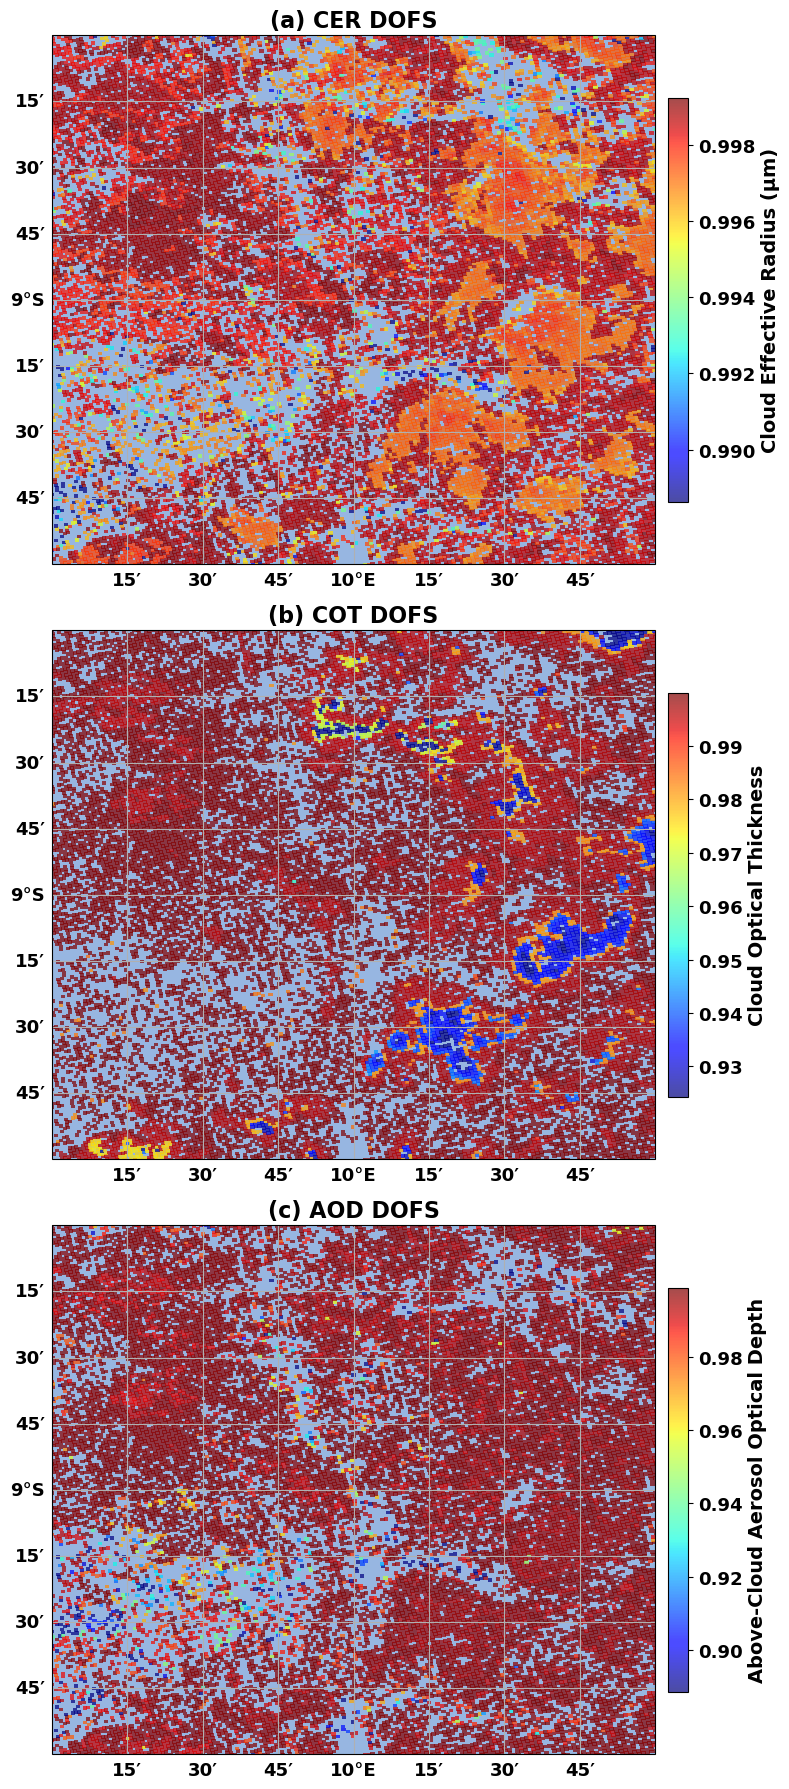

In [16]:
# --------------------------------------------
# Read retrieval maps from NetCDF
# --------------------------------------------
CER_map = ds_clean["DOFS_CER"].values
COT_map = ds_clean["DOFS_COT"].values
AOD_map = ds_clean["DOFS_AOD"].values

# ---- Prepare masked arrays ----
masked_CER = np.ma.masked_invalid(CER_map)
masked_COT = np.ma.masked_invalid(COT_map)
masked_AOD = np.ma.masked_invalid(AOD_map)

param_maps = {
    'CER': masked_CER,
    'COT': masked_COT,
    'AOD': masked_AOD
}

cbar_labels = {
    'CER': 'Cloud Effective Radius (µm)',
    'COT': 'Cloud Optical Thickness',
    'AOD': 'Above-Cloud Aerosol Optical Depth'
}

titles = {
    'CER': '(a) CER DOFS',
    'COT': '(b) COT DOFS',
    'AOD': '(c) AOD DOFS'
}

# --------------------------------------------
# Compute dynamic colorbar ranges (1st–99th percentile)
# --------------------------------------------
cbar_ranges = {}
for param, grid in param_maps.items():
    valid = grid.compressed()
    if len(valid) > 0:
        vmin = np.percentile(valid, 1)
        vmax = np.percentile(valid, 99)
    else:
        vmin, vmax = np.nan, np.nan
    cbar_ranges[param] = (vmin, vmax)

print("Colorbar ranges:")
for param in cbar_ranges:
    print(param, cbar_ranges[param])

# --------------------------------------------
# Coordinates for retrieval grid
# IMPORTANT: use coordinates matching retrieval shape
# --------------------------------------------
lon_plot = lon2d[i0:i1, j0:j1]
lat_plot = lat2d[i0:i1, j0:j1]

print("lon_plot shape:", lon_plot.shape)
print("lat_plot shape:", lat_plot.shape)
print("CER_map shape:", CER_map.shape)
print("COT_map shape:", COT_map.shape)
print("AOD_map shape:", AOD_map.shape)
print("rgb_sub shape:", rgb_sub.shape)

# If retrieval maps and lat/lon subset shapes do not match,
# do not use the cropped RGB overlay
use_rgb = (rgb_sub.shape[:2] == CER_map.shape) and (lon_plot.shape == CER_map.shape)

# --------------------------------------------
# Colormaps
# --------------------------------------------
cmap_dict = {
    'CER': plt.cm.jet.copy(),
    'COT': plt.cm.jet.copy(),
    'AOD': plt.cm.jet.copy()
}

for cmap in cmap_dict.values():
    cmap.set_bad(alpha=0)

# --------------------------------------------
# Create vertical figure
# --------------------------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 18),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (param, grid) in zip(axes, param_maps.items()):

    # --------------------------------------------
    # RGB background only if shape matches
    # --------------------------------------------
    if use_rgb:
        ax.imshow(
            rgb_sub,
            origin='upper',
            extent=[
                np.nanmin(lon_plot), np.nanmax(lon_plot),
                np.nanmin(lat_plot), np.nanmax(lat_plot)
            ],
            transform=ccrs.PlateCarree(),
            aspect='auto'
        )

    # --------------------------------------------
    # Retrieval overlay
    # --------------------------------------------
    cs = ax.pcolormesh(
        lon_plot,
        lat_plot,
        grid,
        cmap=cmap_dict[param],
        shading='nearest',
        vmin=cbar_ranges[param][0],
        vmax=cbar_ranges[param][1],
        alpha=0.70 if use_rgb else 1.0,
        transform=ccrs.PlateCarree()
    )

    # --------------------------------------------
    # Map formatting
    # --------------------------------------------
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=1.0)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.xlabel_style = {'size': 13, 'weight': 'bold'}
    gl.ylabel_style = {'size': 13, 'weight': 'bold'}

    ax.set_title(titles[param], fontsize=16, fontweight='bold')

    # --------------------------------------------
    # Colorbar
    # --------------------------------------------
    cbar = fig.colorbar(cs, ax=ax, fraction=0.0317, pad=0.02)
    cbar.ax.tick_params(labelsize=13)
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    cbar.set_label(
        cbar_labels[param],
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Colorbar ranges:
CER (np.float32(3.2296877), np.float32(5.183235))
COT (np.float32(1.8622918), np.float32(7.0656767))
AOD (np.float32(1.583408), np.float32(4.809802))
lon_plot shape: (216, 189)
lat_plot shape: (216, 189)
CER_map shape: (216, 189)
COT_map shape: (216, 189)
AOD_map shape: (216, 189)
rgb_sub shape: (216, 189, 3)


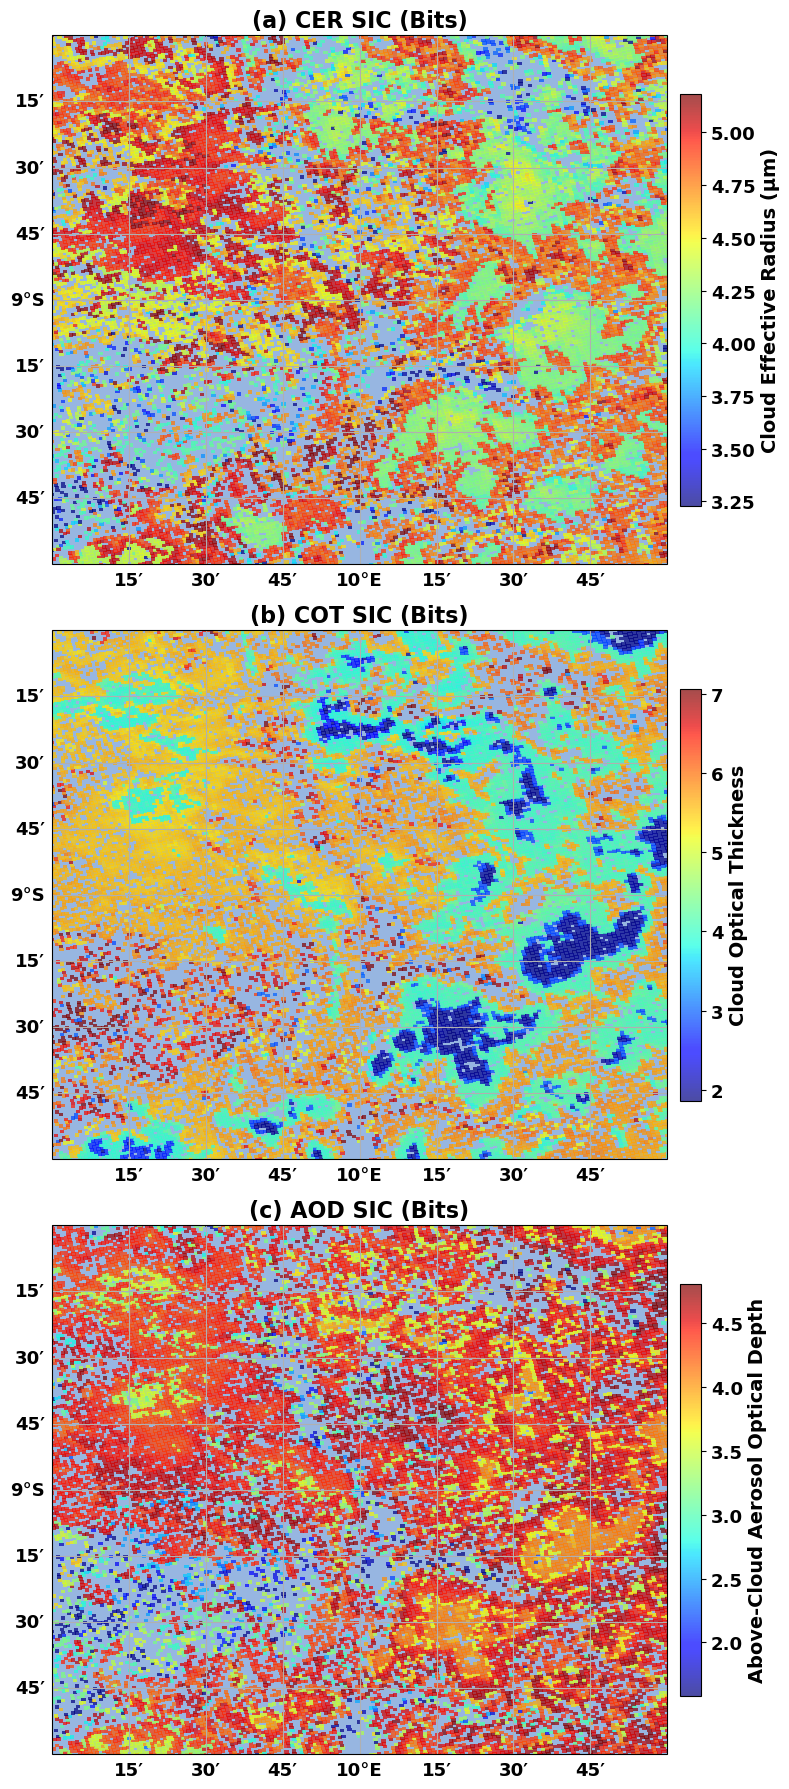

In [13]:
# --------------------------------------------
# Read retrieval maps from NetCDF
# --------------------------------------------
CER_map = ds_clean["SIC_CER_bits"].values
COT_map = ds_clean["SIC_COT_bits"].values
AOD_map = ds_clean["SIC_AOD_bits"].values

# ---- Prepare masked arrays ----
masked_CER = np.ma.masked_invalid(CER_map)
masked_COT = np.ma.masked_invalid(COT_map)
masked_AOD = np.ma.masked_invalid(AOD_map)

param_maps = {
    'CER': masked_CER,
    'COT': masked_COT,
    'AOD': masked_AOD
}

cbar_labels = {
    'CER': 'Cloud Effective Radius (µm)',
    'COT': 'Cloud Optical Thickness',
    'AOD': 'Above-Cloud Aerosol Optical Depth'
}

titles = {
    'CER': '(a) CER SIC (Bits)',
    'COT': '(b) COT SIC (Bits)',
    'AOD': '(c) AOD SIC (Bits)'
}

# --------------------------------------------
# Compute dynamic colorbar ranges (1st–99th percentile)
# --------------------------------------------
cbar_ranges = {}
for param, grid in param_maps.items():
    valid = grid.compressed()
    if len(valid) > 0:
        vmin = np.percentile(valid, 1)
        vmax = np.percentile(valid, 99)
    else:
        vmin, vmax = np.nan, np.nan
    cbar_ranges[param] = (vmin, vmax)

print("Colorbar ranges:")
for param in cbar_ranges:
    print(param, cbar_ranges[param])

# --------------------------------------------
# Coordinates for retrieval grid
# IMPORTANT: use coordinates matching retrieval shape
# --------------------------------------------
lon_plot = lon2d[i0:i1, j0:j1]
lat_plot = lat2d[i0:i1, j0:j1]

print("lon_plot shape:", lon_plot.shape)
print("lat_plot shape:", lat_plot.shape)
print("CER_map shape:", CER_map.shape)
print("COT_map shape:", COT_map.shape)
print("AOD_map shape:", AOD_map.shape)
print("rgb_sub shape:", rgb_sub.shape)

# If retrieval maps and lat/lon subset shapes do not match,
# do not use the cropped RGB overlay
use_rgb = (rgb_sub.shape[:2] == CER_map.shape) and (lon_plot.shape == CER_map.shape)

# --------------------------------------------
# Colormaps
# --------------------------------------------
cmap_dict = {
    'CER': plt.cm.jet.copy(),
    'COT': plt.cm.jet.copy(),
    'AOD': plt.cm.jet.copy()
}

for cmap in cmap_dict.values():
    cmap.set_bad(alpha=0)

# --------------------------------------------
# Create vertical figure
# --------------------------------------------
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 18),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (param, grid) in zip(axes, param_maps.items()):

    # --------------------------------------------
    # RGB background only if shape matches
    # --------------------------------------------
    if use_rgb:
        ax.imshow(
            rgb_sub,
            origin='upper',
            extent=[
                np.nanmin(lon_plot), np.nanmax(lon_plot),
                np.nanmin(lat_plot), np.nanmax(lat_plot)
            ],
            transform=ccrs.PlateCarree(),
            aspect='auto'
        )

    # --------------------------------------------
    # Retrieval overlay
    # --------------------------------------------
    cs = ax.pcolormesh(
        lon_plot,
        lat_plot,
        grid,
        cmap=cmap_dict[param],
        shading='nearest',
        vmin=cbar_ranges[param][0],
        vmax=cbar_ranges[param][1],
        alpha=0.70 if use_rgb else 1.0,
        transform=ccrs.PlateCarree()
    )

    # --------------------------------------------
    # Map formatting
    # --------------------------------------------
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=1.0)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)

    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.xlabel_style = {'size': 13, 'weight': 'bold'}
    gl.ylabel_style = {'size': 13, 'weight': 'bold'}

    ax.set_title(titles[param], fontsize=16, fontweight='bold')

    # --------------------------------------------
    # Colorbar
    # --------------------------------------------
    cbar = fig.colorbar(cs, ax=ax, fraction=0.0317, pad=0.02)
    cbar.ax.tick_params(labelsize=13)
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    cbar.set_label(
        cbar_labels[param],
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()